In [1]:
# ============================================================
# RESET UTILITIES FOR ITERATION 3
# ============================================================

import os
import json
import glob
import shutil

# Iteration 3 paths
DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_Iterations/_iteration_3/checkpoint.json"

def reset_checkpoint():
    """Delete checkpoint to restart from beginning"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint cleared - will restart from beginning")
    else:
        print(" No checkpoint found - already clean")

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
            print(f"\n{'='*60}")
            print(f"ITERATION 3 PROGRESS: {len(processed)} combinations processed")
            print(f"{'='*60}")
            print("\nCompleted:")
            for item in processed:
                if isinstance(item, (list, tuple)) and len(item) >= 2:
                    model, dataset = item[0], item[1]
                    print(f"   {model:40s} → {dataset}")
                else:
                    print(f"   {item}")
    else:
        print(" No checkpoint found - no progress yet")

def reset_embeddings():
    """Delete all generated embeddings for iteration 3"""
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        response = input(f" Delete ALL embeddings in {EMBEDDINGS_BASE_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" All iteration 3 embeddings deleted")
        else:
            print(" Cancelled")
    else:
        print(" Embeddings directory doesn't exist")

def reset_results():
    """Delete all results for iteration 3"""
    if os.path.exists(RESULTS_DIR):
        response = input(f" Delete ALL results in {RESULTS_DIR}? (yes/no): ")
        if response.lower() == 'yes':
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" All iteration 3 results deleted")
        else:
            print(" Cancelled")
    else:
        print(" Results directory doesn't exist")

def full_reset():
    """Complete reset - checkpoint, embeddings, and results"""
    print("\n" + "="*60)
    print(" FULL RESET WARNING - ITERATION 3")
    print("="*60)
    response = input("This will delete EVERYTHING (checkpoint, embeddings, results). Continue? (yes/no): ")
    if response.lower() == 'yes':
        reset_checkpoint()
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        print("\n Full reset complete - Ready for fresh start")
    else:
        print(" Cancelled")

def remove_specific_model(model_key):
    """Remove specific model from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[0] != model_key]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for model: {model_key}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def remove_specific_dataset(dataset_name):
    """Remove specific dataset from checkpoint to reprocess it"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            data = json.load(f)
            processed = data['processed']
        
        original_count = len(processed)
        processed = [item for item in processed if item[1] != dataset_name]
        removed_count = original_count - len(processed)
        
        with open(CHECKPOINT_FILE, 'w') as f:
            json.dump({'processed': processed}, f)
        
        print(f" Removed {removed_count} combinations for dataset: {dataset_name}")
        print(f"Remaining: {len(processed)} combinations")
    else:
        print(" No checkpoint found")

def complete_rerun():
    """Simple one-command complete restart for iteration 3"""
    print("\n" + "="*60)
    print(" COMPLETE RERUN - ITERATION 3")
    print("="*60)
    print("This will:")
    print("  1. Clear checkpoint file")
    print("  2. Delete all embeddings")
    print("  3. Delete all results")
    print("  4. Start fresh from beginning")
    print("="*60)
    response = input("\nProceed with complete rerun? (yes/no): ")
    if response.lower() == 'yes':
        # Clear checkpoint
        if os.path.exists(CHECKPOINT_FILE):
            os.remove(CHECKPOINT_FILE)
            print(" Checkpoint cleared")
        
        # Clear embeddings
        if os.path.exists(EMBEDDINGS_BASE_DIR):
            shutil.rmtree(EMBEDDINGS_BASE_DIR)
            os.makedirs(EMBEDDINGS_BASE_DIR)
            print(" Embeddings deleted")
        
        # Clear results
        if os.path.exists(RESULTS_DIR):
            for file in glob.glob(os.path.join(RESULTS_DIR, '*')):
                os.remove(file)
            print(" Results deleted")
        
        print("\n" + "="*60)
        print(" COMPLETE RERUN READY - ITERATION 3")
        print("="*60)
        print("Now run the main pipeline cell to start fresh!")
        print("="*60)
    else:
        print(" Cancelled")

def show_disk_usage():
    """Show disk usage for iteration 3 files"""
    print("\n" + "="*60)
    print(" DISK USAGE - ITERATION 3")
    print("="*60)
    
    # Embeddings size
    if os.path.exists(EMBEDDINGS_BASE_DIR):
        total_size = 0
        file_count = 0
        for root, dirs, files in os.walk(EMBEDDINGS_BASE_DIR):
            for f in files:
                fp = os.path.join(root, f)
                total_size += os.path.getsize(fp)
                file_count += 1
        print(f"Embeddings: {total_size / 1024**3:.2f} GB ({file_count} files)")
    else:
        print("Embeddings: 0 GB (directory doesn't exist)")
    
    # Results size
    if os.path.exists(RESULTS_DIR):
        total_size = sum(os.path.getsize(os.path.join(RESULTS_DIR, f)) 
                        for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f)))
        file_count = len([f for f in os.listdir(RESULTS_DIR) if os.path.isfile(os.path.join(RESULTS_DIR, f))])
        print(f"Results: {total_size / 1024**2:.2f} MB ({file_count} files)")
    else:
        print("Results: 0 MB (directory doesn't exist)")
    
    print("="*60)

# ============================================================
# Quick Commands - Uncomment the one you want to run
# ============================================================

# View current progress
view_progress()

# Show disk usage
# show_disk_usage()

# To reset just checkpoint (keeps embeddings/results):
# reset_checkpoint()

# To remove a specific model (e.g., to reprocess it):
# remove_specific_model('intfloat/multilingual-e5-large')

# To remove a specific dataset (e.g., to reprocess it):
# remove_specific_dataset('sweden')

# To do a complete rerun:
# complete_rerun()

print("\n" + "="*60)
print(" RESTART UTILITIES LOADED - ITERATION 3")
print("="*60)
print("Available functions:")
print("  view_progress()              - See what's completed")
print("  show_disk_usage()            - Check disk usage")
print("  reset_checkpoint()           - Clear checkpoint only")
print("  remove_specific_model(name)  - Remove model from checkpoint")
print("  remove_specific_dataset(name)- Remove dataset from checkpoint")
print("  reset_embeddings()           - Delete all embeddings")
print("  reset_results()              - Delete all results")
print("  complete_rerun()             - COMPLETE RESTART (everything)")
print("="*60)
print("\n TIP: To completely restart everything, run: complete_rerun()")

 No checkpoint found - no progress yet

 RESTART UTILITIES LOADED - ITERATION 3
Available functions:
  view_progress()              - See what's completed
  show_disk_usage()            - Check disk usage
  reset_checkpoint()           - Clear checkpoint only
  remove_specific_model(name)  - Remove model from checkpoint
  remove_specific_dataset(name)- Remove dataset from checkpoint
  reset_embeddings()           - Delete all embeddings
  reset_results()              - Delete all results
  complete_rerun()             - COMPLETE RESTART (everything)

 TIP: To completely restart everything, run: complete_rerun()


In [2]:
complete_rerun()


 COMPLETE RERUN - ITERATION 3
This will:
  1. Clear checkpoint file
  2. Delete all embeddings
  3. Delete all results
  4. Start fresh from beginning
 Embeddings deleted
 Results deleted

 COMPLETE RERUN READY - ITERATION 3
Now run the main pipeline cell to start fresh!


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



################################################################################
MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE
################################################################################

Models: ['bert-base-multilingual-uncased', 'bert-base-multilingual-cased', 'intfloat/multilingual-e5-base', 'intfloat/multilingual-e5-large', 'intfloat/multilingual-e5-large-instruct']
Batch Size: 8
Max SVM Training Samples: 60000

################################################################################
STARTING PIPELINE EXECUTION
################################################################################

Found 9 total datasets
Skipping 4 datasets:
  - RW_ACTUALS_Hungary.csv
  - RW_ACTUALS_International.csv
  - RW_ACTUALS_Russia.csv
  - RW_ACTUALS_UAE.csv

Processing 5 datasets
Total combinations: 25

Already processed: 0 combinations

################################################################################
MODEL: bert-base-multilingual-uncased (google-ber

/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at google-bert/bert-base-multilingual-uncased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a 

 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-multilingual-uncased

Processing: ENGLISH
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [01:23<00:00, 10.68it/s]


...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2607/2607 [02:56<00:00, 14.80it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/bert-base-multilingual-uncased/sweden_bert-base-multilingual-uncased_embeddings.pkl
Size: 63.47 MB

Checkpoint saved: 4 combinations processed
Progress: 4/25

Processing: UK
Model: bert-base-multilingual-uncased (google-bert/bert-base-multilingual-uncased)
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-uncased embeddings

Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [01:50<00:00,  7.94it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/bert-base-multilingual-uncased/uk_bert-base-multilingual-uncased_embeddings.pkl
Size: 22.88 MB

Checkpoint saved: 5 combinations processed
Progress: 5/25

PHASE 2: TRAINING SVM - bert-base-multilingual-uncased

Training SVM: ENGLISH | Model: bert-base-multilingual-uncased
Training samples: 5675
Test samples: 1419

Training LinearSVC...
Training completed in 3.97s

Accuracy: 0.7844
F1 Score (weighted): 0.7888
F1 Score (macro): 0.7629

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8760    0.7963    0.8342       967
    Process Safety     0.6352    0.7588    0.6915       452

          accuracy                         0.7844      1419
         macro avg     0.7556    0.

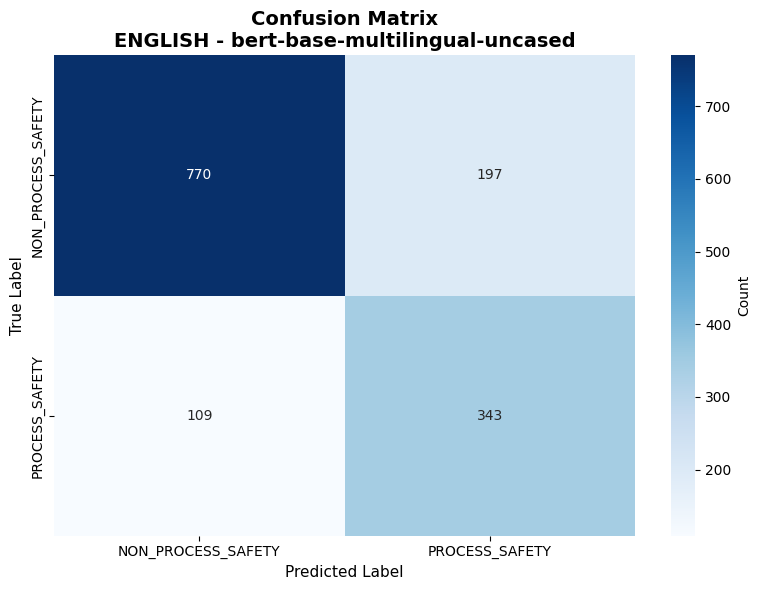


Training SVM: GERMANY | Model: bert-base-multilingual-uncased
Training samples: 18268
Test samples: 4568

Training LinearSVC...
Training completed in 14.45s

Accuracy: 0.8001
F1 Score (weighted): 0.8275
F1 Score (macro): 0.6702

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9549    0.8112    0.8772      4020
    Process Safety     0.3417    0.7190    0.4633       548

          accuracy                         0.8001      4568
         macro avg     0.6483    0.7651    0.6702      4568
      weighted avg     0.8813    0.8001    0.8275      4568


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_germany_bert-base-multilingual-uncased.png


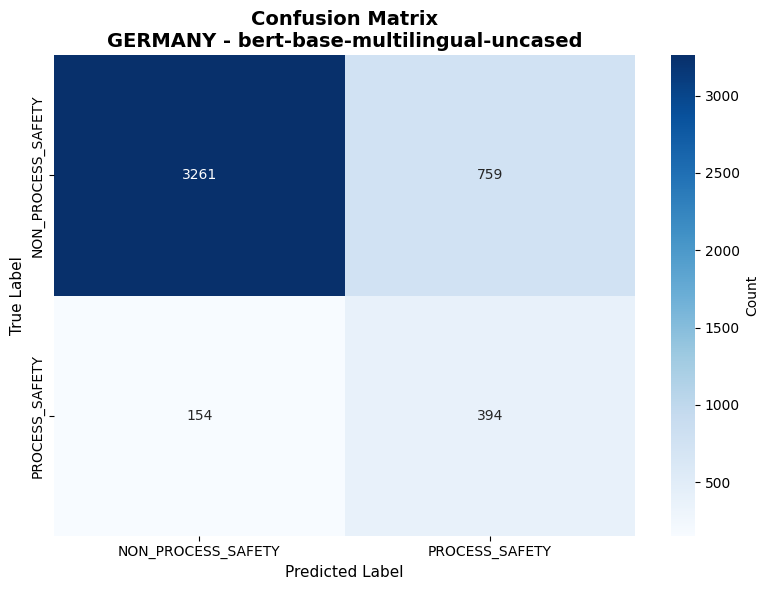


Training SVM: NETHERLANDS | Model: bert-base-multilingual-uncased
Training samples: 2534
Test samples: 634

Training LinearSVC...
Training completed in 1.18s

Accuracy: 0.7571
F1 Score (weighted): 0.7631
F1 Score (macro): 0.7337

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8630    0.7678    0.8127       435
    Process Safety     0.5911    0.7337    0.6547       199

          accuracy                         0.7571       634
         macro avg     0.7271    0.7507    0.7337       634
      weighted avg     0.7777    0.7571    0.7631       634


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_netherlands_bert-base-multilingual-uncased.png


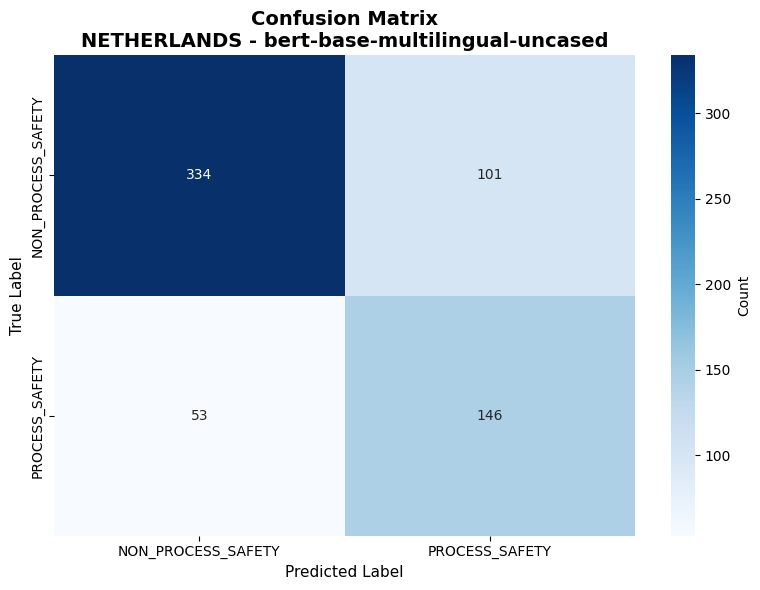


Training SVM: SWEDEN | Model: bert-base-multilingual-uncased
Training samples: 16680
Test samples: 4171

Training LinearSVC...
Training completed in 21.69s

Accuracy: 0.7847
F1 Score (weighted): 0.8340
F1 Score (macro): 0.5974

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9761    0.7880    0.8720      3882
    Process Safety     0.2064    0.7405    0.3228       289

          accuracy                         0.7847      4171
         macro avg     0.5912    0.7642    0.5974      4171
      weighted avg     0.9227    0.7847    0.8340      4171


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_sweden_bert-base-multilingual-uncased.png


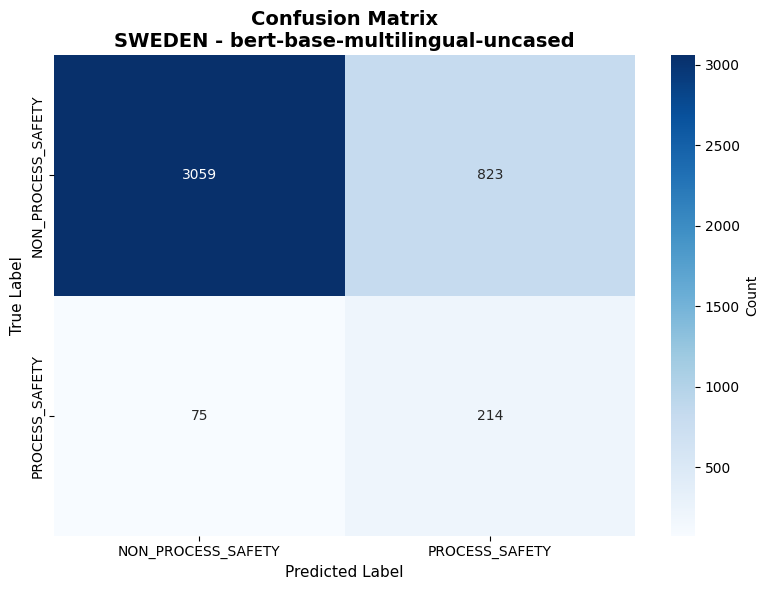


Training SVM: UK | Model: bert-base-multilingual-uncased
Training samples: 5615
Test samples: 1404

Training LinearSVC...
Training completed in 6.84s

Accuracy: 0.7999
F1 Score (weighted): 0.8037
F1 Score (macro): 0.7777

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8847    0.8139    0.8479       962
    Process Safety     0.6551    0.7692    0.7076       442

          accuracy                         0.7999      1404
         macro avg     0.7699    0.7916    0.7777      1404
      weighted avg     0.8125    0.7999    0.8037      1404


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_uk_bert-base-multilingual-uncased.png


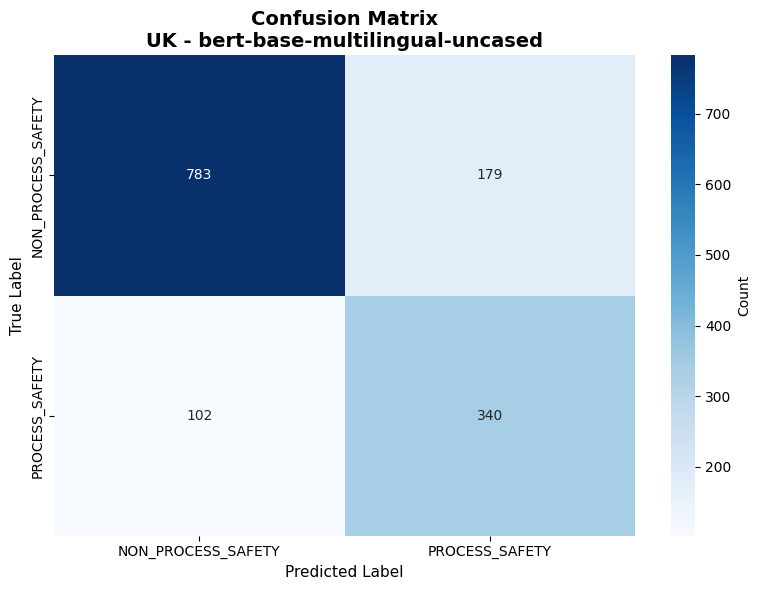


 Completed processing bert-base-multilingual-uncased

################################################################################
MODEL: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
################################################################################

Initializing bert-base-multilingual-cased...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of the model checkpoint at google-bert/bert-base-multilingual-cased were not used when initializing BertModel: ['cls.seq_relationship.weight', 'cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a mo

 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - bert-base-multilingual-cased

Processing: ENGLISH
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [01:48<00:00,  8.21it/s]



Training set: (5675, 768)
Test set: (1419, 768)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/bert-base-multilingual-cased/english_bert-base-multilingual-cased_embeddings.pkl
Size: 23.15 MB

Checkpoint saved: 6 combinations processed
Progress: 6/25

Processing: GERMANY
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embedd

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2607/2607 [03:33<00:00, 12.24it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/bert-base-multilingual-cased/sweden_bert-base-multilingual-cased_embeddings.pkl
Size: 63.47 MB

Checkpoint saved: 9 combinations processed
Progress: 9/25

Processing: UK
Model: bert-base-multilingual-cased (google-bert/bert-base-multilingual-cased)
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating google-bert/bert-base-multilingual-cased embeddings...
Using 

Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [01:28<00:00,  9.91it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/bert-base-multilingual-cased/uk_bert-base-multilingual-cased_embeddings.pkl
Size: 22.88 MB

Checkpoint saved: 10 combinations processed
Progress: 10/25

PHASE 2: TRAINING SVM - bert-base-multilingual-cased

Training SVM: ENGLISH | Model: bert-base-multilingual-cased
Training samples: 5675
Test samples: 1419

Training LinearSVC...
Training completed in 15.50s

Accuracy: 0.7738
F1 Score (weighted): 0.7787
F1 Score (macro): 0.7521

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8704    0.7849    0.8254       967
    Process Safety     0.6197    0.7500    0.6787       452

          accuracy                         0.7738      1419
         macro avg     0.7451    0.7675 

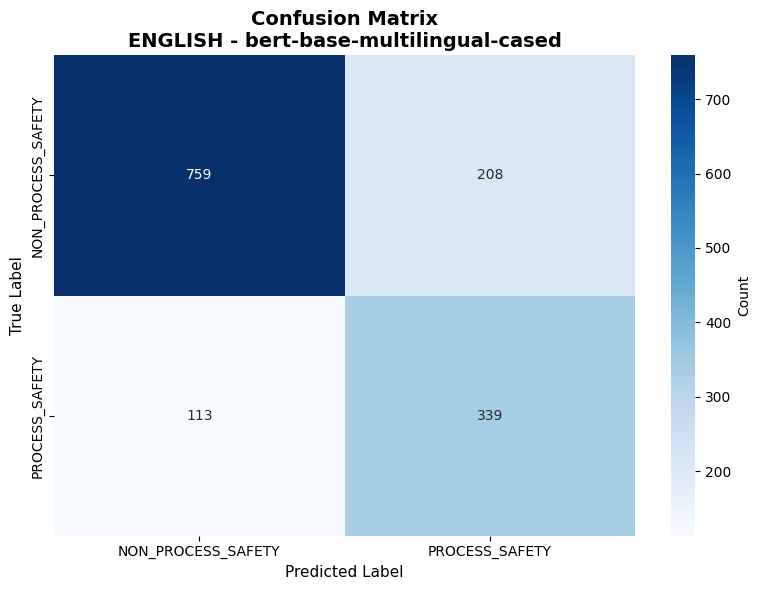


Training SVM: GERMANY | Model: bert-base-multilingual-cased
Training samples: 18268
Test samples: 4568

Training LinearSVC...
Training completed in 33.59s

Accuracy: 0.7949
F1 Score (weighted): 0.8243
F1 Score (macro): 0.6701

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9592    0.8010    0.8730      4020
    Process Safety     0.3394    0.7500    0.4673       548

          accuracy                         0.7949      4568
         macro avg     0.6493    0.7755    0.6701      4568
      weighted avg     0.8848    0.7949    0.8243      4568


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_germany_bert-base-multilingual-cased.png


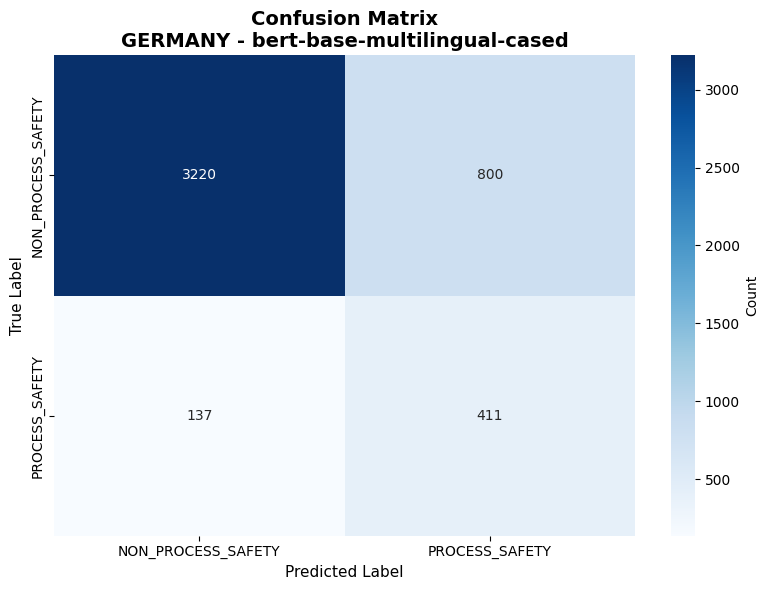


Training SVM: NETHERLANDS | Model: bert-base-multilingual-cased
Training samples: 2534
Test samples: 634

Training LinearSVC...
Training completed in 3.45s

Accuracy: 0.7618
F1 Score (weighted): 0.7669
F1 Score (macro): 0.7364

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8586    0.7816    0.8183       435
    Process Safety     0.6008    0.7186    0.6545       199

          accuracy                         0.7618       634
         macro avg     0.7297    0.7501    0.7364       634
      weighted avg     0.7777    0.7618    0.7669       634


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_netherlands_bert-base-multilingual-cased.png


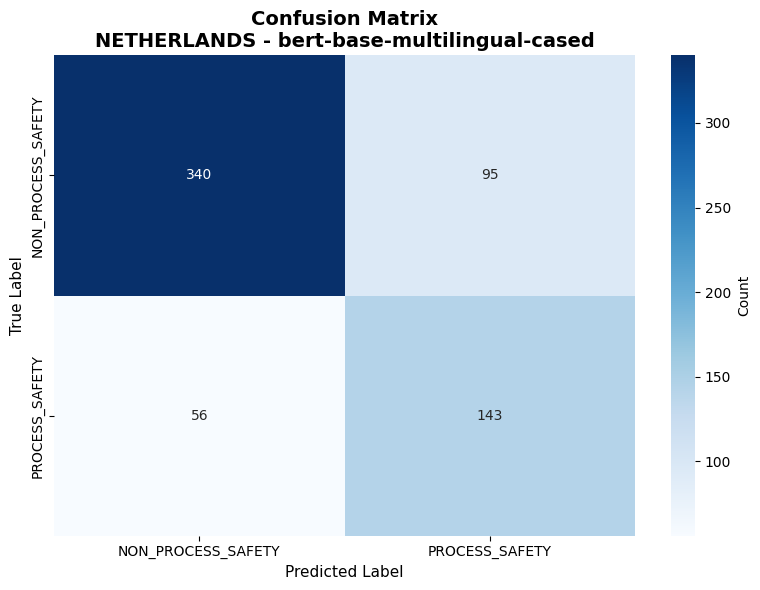


Training SVM: SWEDEN | Model: bert-base-multilingual-cased
Training samples: 16680
Test samples: 4171

Training LinearSVC...
Training completed in 33.99s

Accuracy: 0.8032
F1 Score (weighted): 0.8462
F1 Score (macro): 0.6077

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9734    0.8107    0.8846      3882
    Process Safety     0.2164    0.7024    0.3309       289

          accuracy                         0.8032      4171
         macro avg     0.5949    0.7565    0.6077      4171
      weighted avg     0.9209    0.8032    0.8462      4171


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_sweden_bert-base-multilingual-cased.png


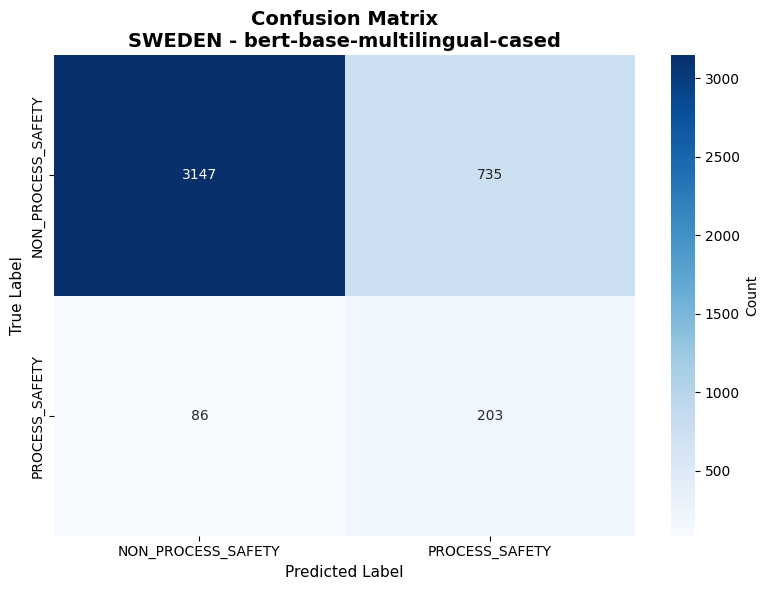


Training SVM: UK | Model: bert-base-multilingual-cased
Training samples: 5615
Test samples: 1404

Training LinearSVC...
Training completed in 9.74s

Accuracy: 0.7771
F1 Score (weighted): 0.7822
F1 Score (macro): 0.7550

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8760    0.7859    0.8285       962
    Process Safety     0.6192    0.7579    0.6816       442

          accuracy                         0.7771      1404
         macro avg     0.7476    0.7719    0.7550      1404
      weighted avg     0.7952    0.7771    0.7822      1404


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_uk_bert-base-multilingual-cased.png


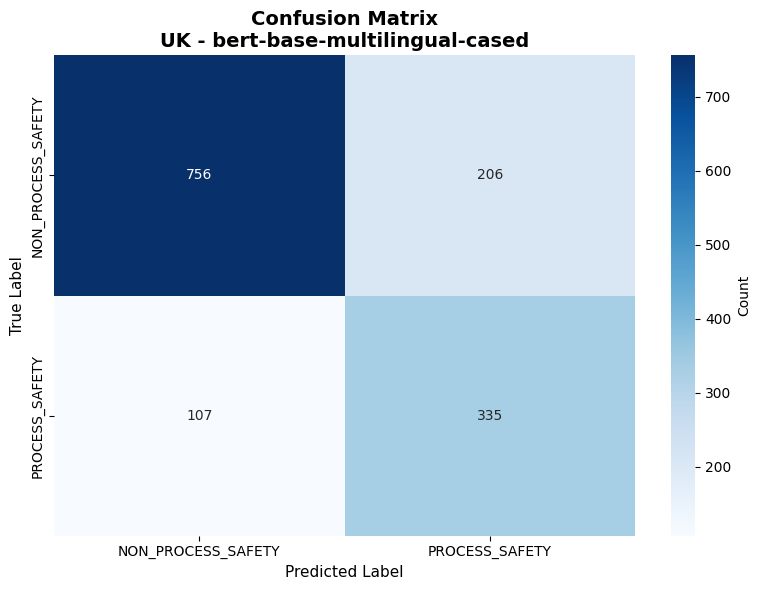


 Completed processing bert-base-multilingual-cased

################################################################################
MODEL: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
################################################################################

Initializing intfloat/multilingual-e5-base...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-base

Processing: ENGLISH
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [01:28<00:00, 10.01it/s]



Training set: (5675, 768)
Test set: (1419, 768)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-base/english_intfloat_multilingual-e5-base_embeddings.pkl
Size: 23.15 MB

Checkpoint saved: 11 combinations processed
Progress: 11/25

Processing: GERMANY
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using dev

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2607/2607 [03:56<00:00, 11.01it/s]



Training set: (16680, 768)
Test set: (4171, 768)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-base/sweden_intfloat_multilingual-e5-base_embeddings.pkl
Size: 63.47 MB

Checkpoint saved: 14 combinations processed
Progress: 14/25

Processing: UK
Model: intfloat/multilingual-e5-base (intfloat/multilingual-e5-base)
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-base embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [01:42<00:00,  8.60it/s]



Training set: (5615, 768)
Test set: (1404, 768)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-base/uk_intfloat_multilingual-e5-base_embeddings.pkl
Size: 22.88 MB

Checkpoint saved: 15 combinations processed
Progress: 15/25

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-base

Training SVM: ENGLISH | Model: intfloat/multilingual-e5-base
Training samples: 5675
Test samples: 1419

Training LinearSVC...
Training completed in 9.21s

Accuracy: 0.8252
F1 Score (weighted): 0.8291
F1 Score (macro): 0.8087

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9137    0.8211    0.8649       967
    Process Safety     0.6855    0.8341    0.7525       452

          accuracy                         0.8252      1419
         macro avg     0.7996    0.82

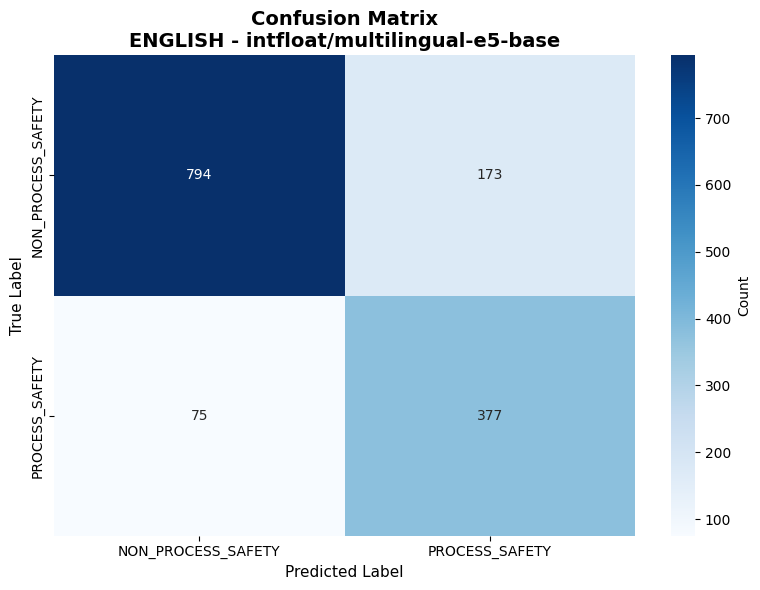


Training SVM: GERMANY | Model: intfloat/multilingual-e5-base
Training samples: 18268
Test samples: 4568

Training LinearSVC...
Training completed in 51.90s

Accuracy: 0.8168
F1 Score (weighted): 0.8410
F1 Score (macro): 0.6918

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9604    0.8259    0.8881      4020
    Process Safety     0.3699    0.7500    0.4955       548

          accuracy                         0.8168      4568
         macro avg     0.6652    0.7879    0.6918      4568
      weighted avg     0.8895    0.8168    0.8410      4568


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_germany_intfloat_multilingual-e5-base.png


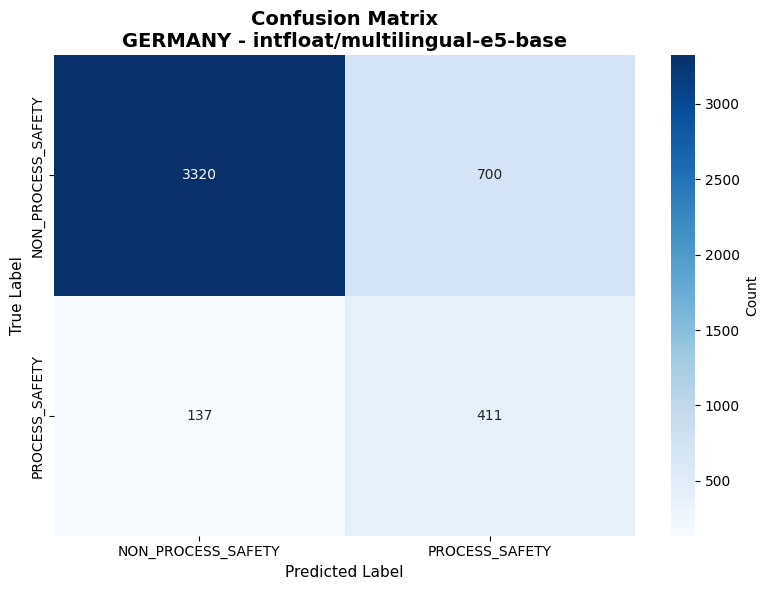


Training SVM: NETHERLANDS | Model: intfloat/multilingual-e5-base
Training samples: 2534
Test samples: 634

Training LinearSVC...
Training completed in 5.39s

Accuracy: 0.8186
F1 Score (weighted): 0.8220
F1 Score (macro): 0.7979

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8980    0.8299    0.8626       435
    Process Safety     0.6810    0.7940    0.7332       199

          accuracy                         0.8186       634
         macro avg     0.7895    0.8119    0.7979       634
      weighted avg     0.8299    0.8186    0.8220       634


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_netherlands_intfloat_multilingual-e5-base.png


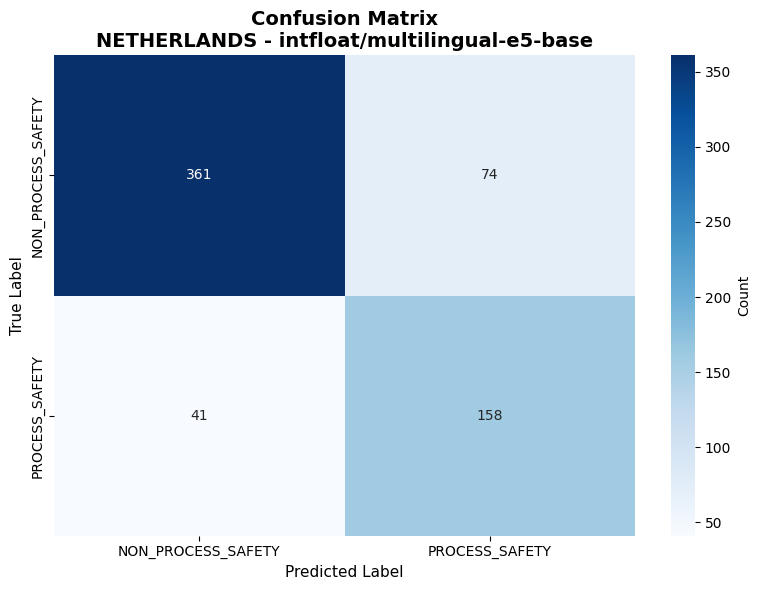


Training SVM: SWEDEN | Model: intfloat/multilingual-e5-base
Training samples: 16680
Test samples: 4171

Training LinearSVC...
Training completed in 45.27s

Accuracy: 0.8231
F1 Score (weighted): 0.8610
F1 Score (macro): 0.6388

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9810    0.8259    0.8968      3882
    Process Safety     0.2514    0.7855    0.3809       289

          accuracy                         0.8231      4171
         macro avg     0.6162    0.8057    0.6388      4171
      weighted avg     0.9305    0.8231    0.8610      4171


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_sweden_intfloat_multilingual-e5-base.png


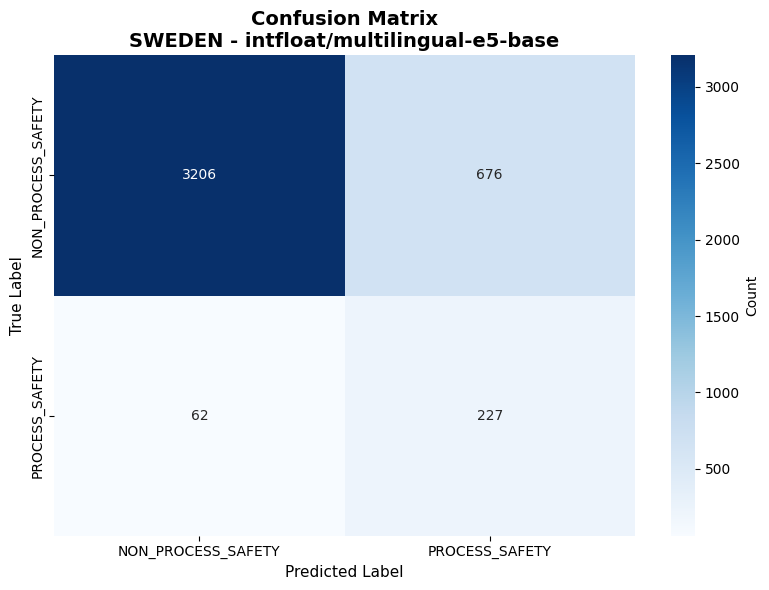


Training SVM: UK | Model: intfloat/multilingual-e5-base
Training samples: 5615
Test samples: 1404

Training LinearSVC...
Training completed in 9.80s

Accuracy: 0.8141
F1 Score (weighted): 0.8173
F1 Score (macro): 0.7925

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8916    0.8295    0.8595       962
    Process Safety     0.6778    0.7805    0.7256       442

          accuracy                         0.8141      1404
         macro avg     0.7847    0.8050    0.7925      1404
      weighted avg     0.8243    0.8141    0.8173      1404


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_uk_intfloat_multilingual-e5-base.png


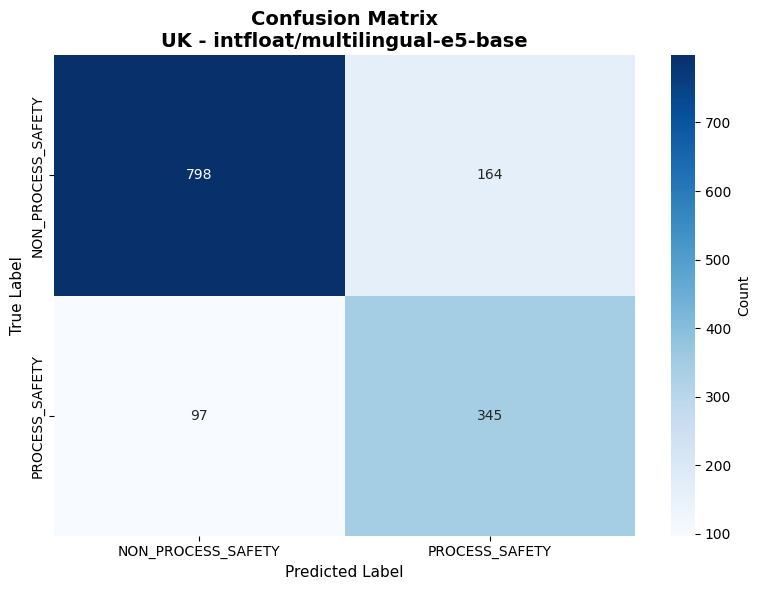


 Completed processing intfloat/multilingual-e5-base

################################################################################
MODEL: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
################################################################################

Initializing intfloat/multilingual-e5-large...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large

Processing: ENGLISH
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [03:34<00:00,  4.13it/s]



Training set: (5675, 1024)
Test set: (1419, 1024)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large/english_intfloat_multilingual-e5-large_embeddings.pkl
Size: 30.07 MB

Checkpoint saved: 16 combinations processed
Progress: 16/25

Processing: GERMANY
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Us

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2607/2607 [04:19<00:00, 10.03it/s]



Training set: (16680, 1024)
Test set: (4171, 1024)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large/sweden_intfloat_multilingual-e5-large_embeddings.pkl
Size: 83.83 MB

Checkpoint saved: 19 combinations processed
Progress: 19/25

Processing: UK
Model: intfloat/multilingual-e5-large (intfloat/multilingual-e5-large)
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large embeddings...
Using device: cu

Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [03:35<00:00,  4.08it/s]



Training set: (5615, 1024)
Test set: (1404, 1024)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large/uk_intfloat_multilingual-e5-large_embeddings.pkl
Size: 29.73 MB

Checkpoint saved: 20 combinations processed
Progress: 20/25

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large

Training SVM: ENGLISH | Model: intfloat/multilingual-e5-large
Training samples: 5675
Test samples: 1419

Training LinearSVC...
Training completed in 15.43s

Accuracy: 0.8182
F1 Score (weighted): 0.8212
F1 Score (macro): 0.7980

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8935    0.8325    0.8619       967
    Process Safety     0.6873    0.7876    0.7340       452

          accuracy                         0.8182      1419
         macro avg     0.7904 

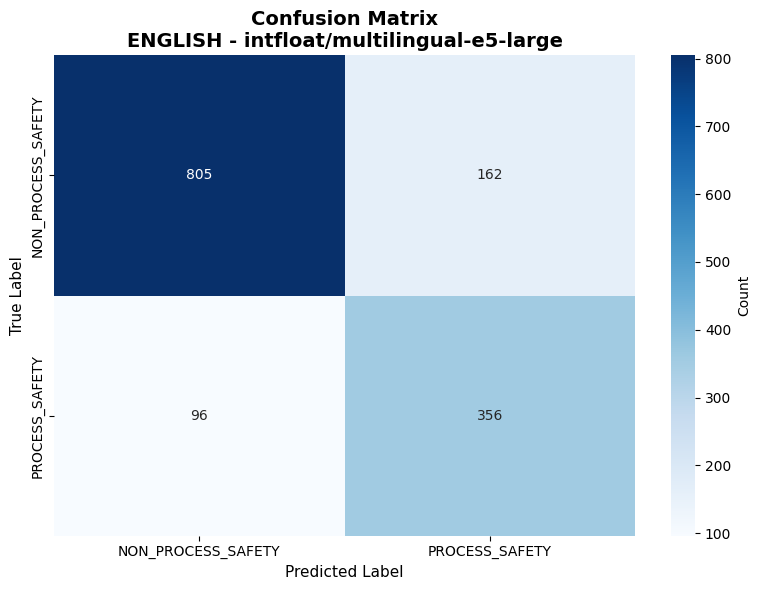


Training SVM: GERMANY | Model: intfloat/multilingual-e5-large
Training samples: 18268
Test samples: 4568

Training LinearSVC...
Training completed in 51.31s

Accuracy: 0.8260
F1 Score (weighted): 0.8489
F1 Score (macro): 0.7072

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9664    0.8311    0.8937      4020
    Process Safety     0.3888    0.7883    0.5208       548

          accuracy                         0.8260      4568
         macro avg     0.6776    0.8097    0.7072      4568
      weighted avg     0.8972    0.8260    0.8489      4568


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_germany_intfloat_multilingual-e5-large.png


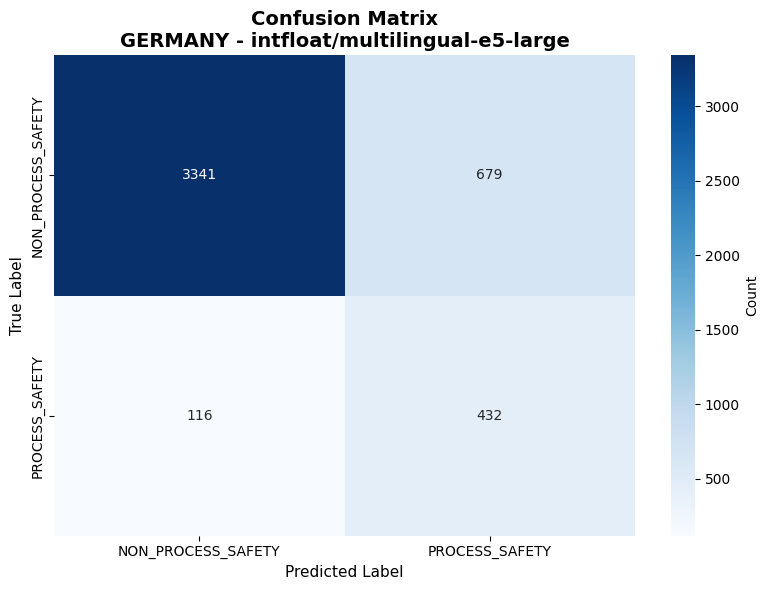


Training SVM: NETHERLANDS | Model: intfloat/multilingual-e5-large
Training samples: 2534
Test samples: 634

Training LinearSVC...
Training completed in 11.76s

Accuracy: 0.8628
F1 Score (weighted): 0.8642
F1 Score (macro): 0.8442

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9163    0.8805    0.8980       435
    Process Safety     0.7593    0.8241    0.7904       199

          accuracy                         0.8628       634
         macro avg     0.8378    0.8523    0.8442       634
      weighted avg     0.8670    0.8628    0.8642       634


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_netherlands_intfloat_multilingual-e5-large.png


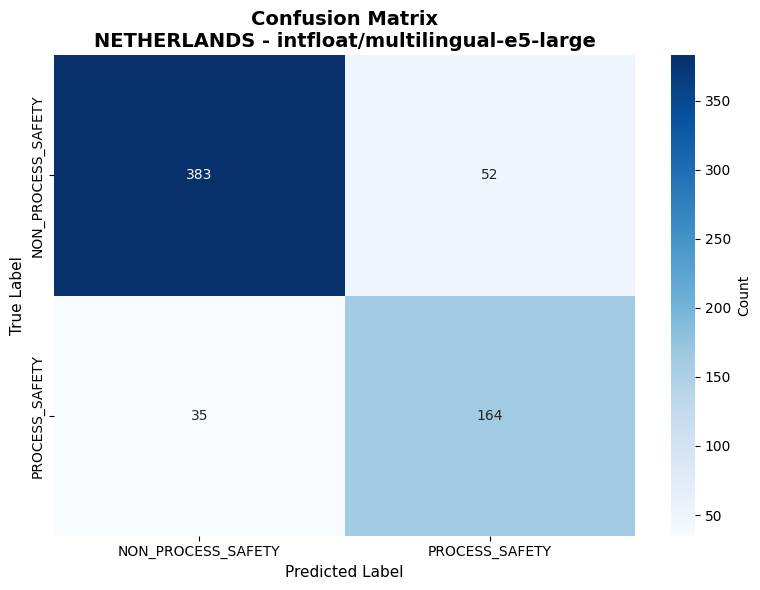


Training SVM: SWEDEN | Model: intfloat/multilingual-e5-large
Training samples: 16680
Test samples: 4171

Training LinearSVC...
Training completed in 57.17s

Accuracy: 0.8384
F1 Score (weighted): 0.8712
F1 Score (macro): 0.6503

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9791    0.8444    0.9068      3882
    Process Safety     0.2661    0.7578    0.3939       289

          accuracy                         0.8384      4171
         macro avg     0.6226    0.8011    0.6503      4171
      weighted avg     0.9297    0.8384    0.8712      4171


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_sweden_intfloat_multilingual-e5-large.png


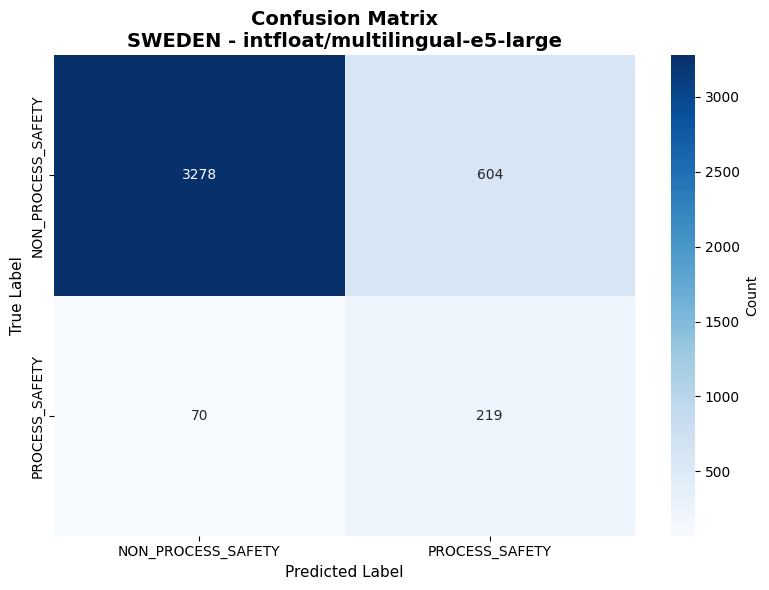


Training SVM: UK | Model: intfloat/multilingual-e5-large
Training samples: 5615
Test samples: 1404

Training LinearSVC...
Training completed in 14.26s

Accuracy: 0.8234
F1 Score (weighted): 0.8271
F1 Score (macro): 0.8047

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9075    0.8264    0.8651       962
    Process Safety     0.6837    0.8167    0.7443       442

          accuracy                         0.8234      1404
         macro avg     0.7956    0.8216    0.8047      1404
      weighted avg     0.8371    0.8234    0.8271      1404


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_uk_intfloat_multilingual-e5-large.png


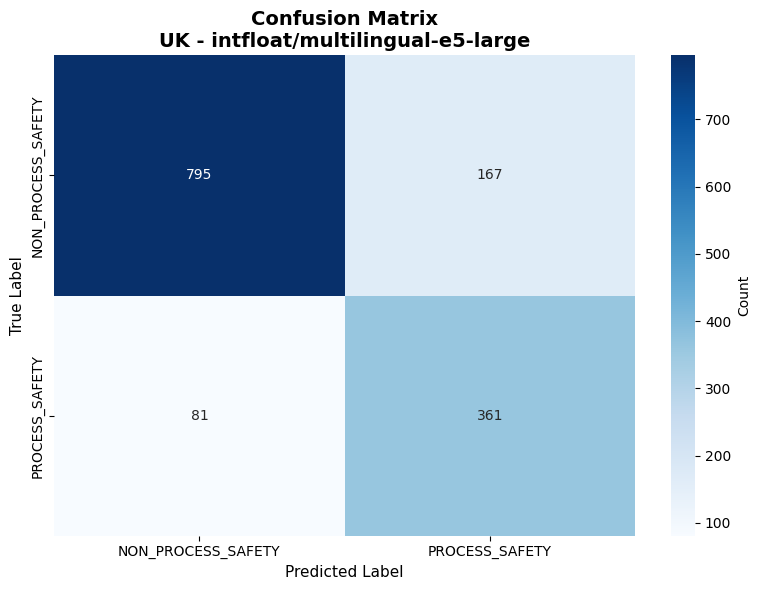


 Completed processing intfloat/multilingual-e5-large

################################################################################
MODEL: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
################################################################################

Initializing intfloat/multilingual-e5-large-instruct...


/anaconda/envs/azureml_py310_sdkv2/lib/python3.10/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


 Model loaded successfully!

PHASE 1: GENERATING EMBEDDINGS - intfloat/multilingual-e5-large-instruct

Processing: ENGLISH
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (7094, 36)

Case type distribution:
CASE_TYPE
Safety                              3514
Process Safety                      2260
Environment                          778
Asset and Reputation damage/loss     223
Operational loss                     198
Information Security                  22
Physical Security                     16
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large-instruct embeddings...
Using device: cuda


Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 887/887 [03:04<00:00,  4.80it/s]



Training set: (5675, 1024)
Test set: (1419, 1024)

Class distribution in training set:
binary_label
0    68.14%
1    31.86%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/english_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 30.07 MB

Checkpoint saved: 21 combinations processed
Progress: 21/25

Processing: GERMANY
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (22836, 36)

Case type distribution:
CASE_TYPE
Safety                              16740
Process Safety                       2738
Environment                          1711
Asset and Reputation damage/loss      969
Information Security                  274
Operational loss                       88
Physical Security                      30
Not classified                          2
Name: count, dtype: int64

Generating intfloat/mu

...

Dataset shape: (20851, 36)

Case type distribution:
CASE_TYPE
Safety                              16904
Process Safety                       1447
Environment                          1078
Asset and Reputation damage/loss      942
Operational loss                      474
Name: count, dtype: int64

Generating intfloat/multilingual-e5-large-instruct embeddings...
Using device: cuda


Generating embeddings: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2607/2607 [06:13<00:00,  6.97it/s]



Training set: (16680, 1024)
Test set: (4171, 1024)

Class distribution in training set:
binary_label
0    93.06%
1     6.94%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/sweden_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 83.83 MB

Checkpoint saved: 24 combinations processed
Progress: 24/25

Processing: UK
Model: intfloat/multilingual-e5-large-instruct (intfloat/multilingual-e5-large-instruct)
Dataset shape: (7019, 36)

Case type distribution:
CASE_TYPE
Safety                              3497
Process Safety                      2211
Environment                          773
Asset and Reputation damage/loss     221
Operational loss                     197
Information Security                  22
Physical Security                     15
Not classified                         3
Name: count, dtype: int64

Generating intfloat/multilingual-e5-

Generating embeddings: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 878/878 [03:47<00:00,  3.86it/s]



Training set: (5615, 1024)
Test set: (1404, 1024)

Class distribution in training set:
binary_label
0    68.50%
1    31.50%
Name: proportion, dtype: object

Embeddings saved!
Location: /home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3/intfloat_multilingual-e5-large-instruct/uk_intfloat_multilingual-e5-large-instruct_embeddings.pkl
Size: 29.73 MB

Checkpoint saved: 25 combinations processed
Progress: 25/25

PHASE 2: TRAINING SVM - intfloat/multilingual-e5-large-instruct

Training SVM: ENGLISH | Model: intfloat/multilingual-e5-large-instruct
Training samples: 5675
Test samples: 1419

Training LinearSVC...
Training completed in 19.75s

Accuracy: 0.8358
F1 Score (weighted): 0.8382
F1 Score (macro): 0.8167

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9033    0.8501    0.8759       967
    Process Safety     0.7151    0.8053    0.7575       452

          accuracy                         0.8358     

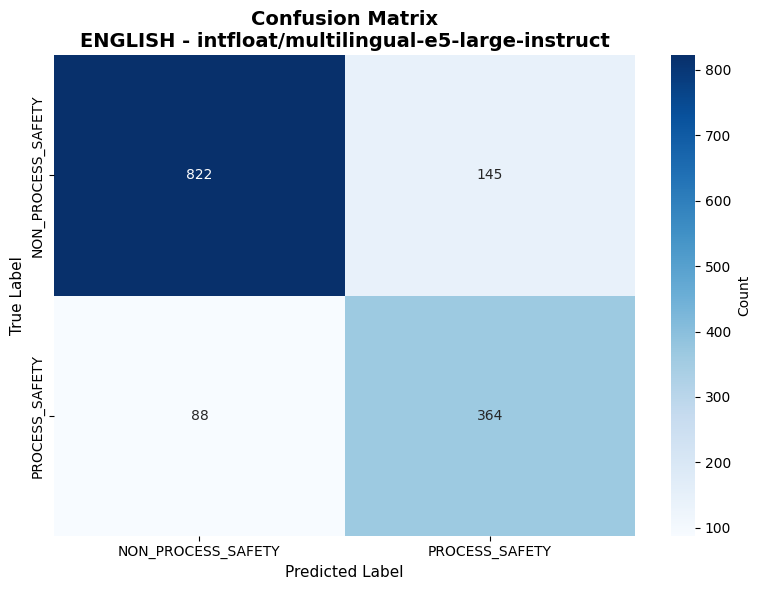


Training SVM: GERMANY | Model: intfloat/multilingual-e5-large-instruct
Training samples: 18268
Test samples: 4568

Training LinearSVC...
Training completed in 86.11s

Accuracy: 0.8260
F1 Score (weighted): 0.8490
F1 Score (macro): 0.7078

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9670    0.8306    0.8936      4020
    Process Safety     0.3892    0.7920    0.5219       548

          accuracy                         0.8260      4568
         macro avg     0.6781    0.8113    0.7078      4568
      weighted avg     0.8977    0.8260    0.8490      4568


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_germany_intfloat_multilingual-e5-large-instruct.png


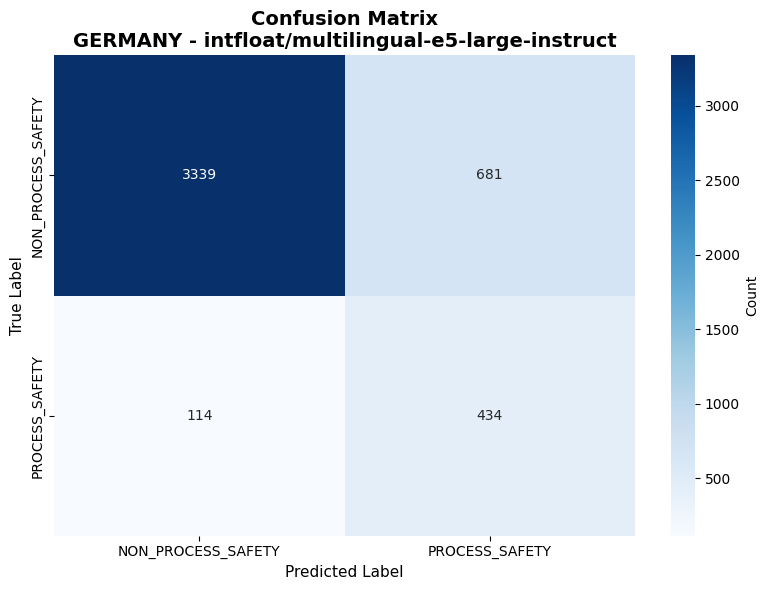


Training SVM: NETHERLANDS | Model: intfloat/multilingual-e5-large-instruct
Training samples: 2534
Test samples: 634

Training LinearSVC...
Training completed in 12.75s

Accuracy: 0.8502
F1 Score (weighted): 0.8501
F1 Score (macro): 0.8258

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8899    0.8920    0.8909       435
    Process Safety     0.7626    0.7588    0.7607       199

          accuracy                         0.8502       634
         macro avg     0.8263    0.8254    0.8258       634
      weighted avg     0.8500    0.8502    0.8501       634


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_netherlands_intfloat_multilingual-e5-large-instruct.png


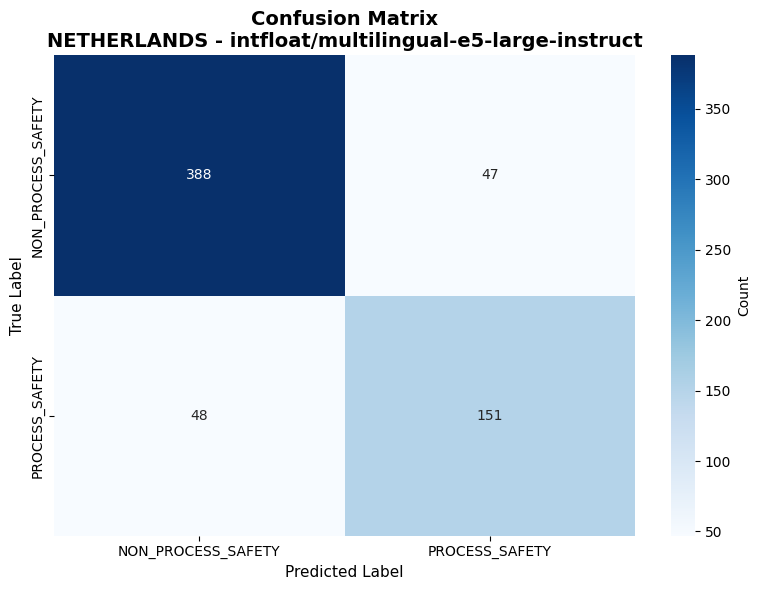


Training SVM: SWEDEN | Model: intfloat/multilingual-e5-large-instruct
Training samples: 16680
Test samples: 4171

Training LinearSVC...
Training completed in 69.68s

Accuracy: 0.8473
F1 Score (weighted): 0.8774
F1 Score (macro): 0.6599

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.9793    0.8539    0.9123      3882
    Process Safety     0.2786    0.7578    0.4074       289

          accuracy                         0.8473      4171
         macro avg     0.6290    0.8059    0.6599      4171
      weighted avg     0.9308    0.8473    0.8774      4171


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_sweden_intfloat_multilingual-e5-large-instruct.png


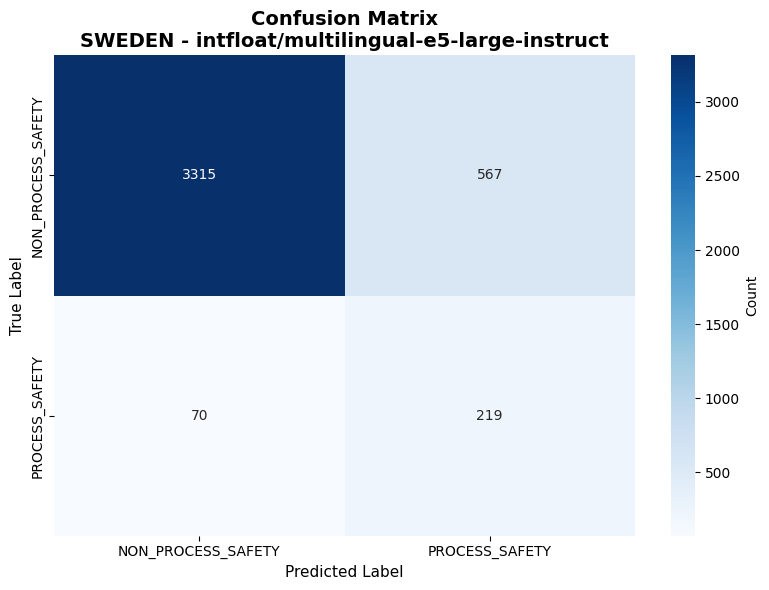


Training SVM: UK | Model: intfloat/multilingual-e5-large-instruct
Training samples: 5615
Test samples: 1404

Training LinearSVC...
Training completed in 17.59s

Accuracy: 0.8283
F1 Score (weighted): 0.8308
F1 Score (macro): 0.8070

Classification Report:
                    precision    recall  f1-score   support

Non-Process Safety     0.8966    0.8472    0.8712       962
    Process Safety     0.7030    0.7873    0.7428       442

          accuracy                         0.8283      1404
         macro avg     0.7998    0.8173    0.8070      1404
      weighted avg     0.8357    0.8283    0.8308      1404


 Confusion matrix saved to: /home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3/cm_uk_intfloat_multilingual-e5-large-instruct.png


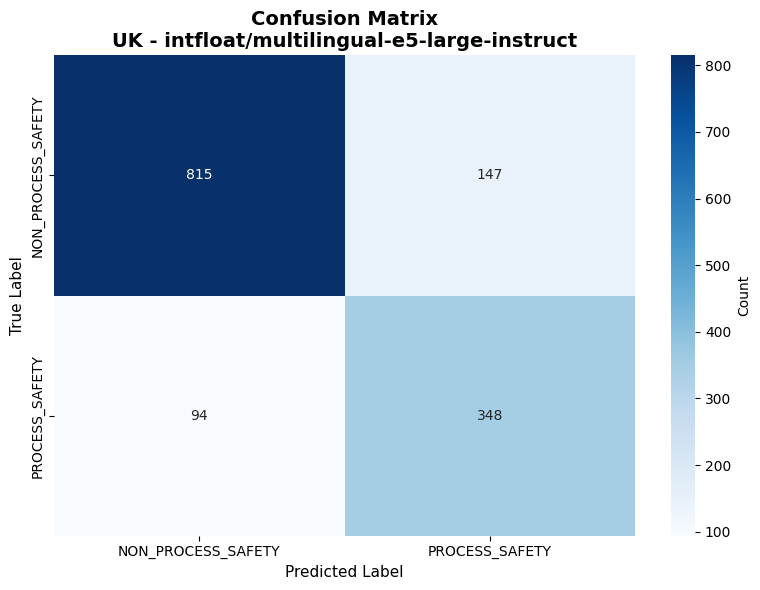


 Completed processing intfloat/multilingual-e5-large-instruct

################################################################################
FINAL COMPREHENSIVE SUMMARY
################################################################################

DETAILED RESULTS TABLE
    dataset                                   model  accuracy  f1_weighted  f1_macro  precision_non_ps  recall_non_ps  f1_non_ps  support_non_ps  precision_ps  recall_ps  f1_ps  support_ps  training_time  subsampled
    english          bert-base-multilingual-uncased    0.7844       0.7888    0.7629            0.8760         0.7963     0.8342             967        0.6352     0.7588 0.6915         452           3.97       False
    germany          bert-base-multilingual-uncased    0.8001       0.8275    0.6702            0.9549         0.8112     0.8772            4020        0.3417     0.7190 0.4633         548          14.45       False
netherlands          bert-base-multilingual-uncased    0.7571       0.7631

In [3]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_recall_fscore_support
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
import torch
from tqdm import tqdm
import pickle
import glob
import gc
import json
import time

# ============================================================
# Configuration
# ============================================================

DATA_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/By_Country/"
EMBEDDINGS_BASE_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Datasets/Embeddings/_iteration_3"
RESULTS_DIR = "/home/azureuser/cloudfiles/code/Users/M02555/Results/_iteration_3"
CHECKPOINT_FILE = "/home/azureuser/cloudfiles/code/Users/M02555/_Iterations/_iteration_3/checkpoint.json"

# Create directories
os.makedirs(EMBEDDINGS_BASE_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.dirname(CHECKPOINT_FILE), exist_ok=True)

# Model configurations - Add Llama model
MODELS = {
    'bert-base-multilingual-uncased': 'google-bert/bert-base-multilingual-uncased',
    'bert-base-multilingual-cased': 'google-bert/bert-base-multilingual-cased',
    'intfloat/multilingual-e5-base': 'intfloat/multilingual-e5-base',
    'intfloat/multilingual-e5-large': 'intfloat/multilingual-e5-large',
    'intfloat/multilingual-e5-large-instruct': 'intfloat/multilingual-e5-large-instruct'
}

# Datasets to skip
SKIP_DATASETS = [
    'RW_ACTUALS_Hungary.csv',
    'RW_ACTUALS_International.csv',
    'RW_ACTUALS_Russia.csv',
    'RW_ACTUALS_UAE.csv'
]

# Processing settings
BATCH_SIZE = 8
MAX_SAMPLES_SVM = 60000

print("\n" + "#"*80)
print("MULTI-MODEL EMBEDDING AND SVM TRAINING PIPELINE")
print("#"*80)
print(f"\nModels: {list(MODELS.keys())}")
print(f"Batch Size: {BATCH_SIZE}")
print(f"Max SVM Training Samples: {MAX_SAMPLES_SVM}")

# ============================================================
# Checkpoint Functions
# ============================================================

def save_checkpoint(processed_items):
    """Save checkpoint with processed model-dataset combinations"""
    with open(CHECKPOINT_FILE, 'w') as f:
        json.dump({'processed': list(processed_items)}, f)
    print(f"Checkpoint saved: {len(processed_items)} combinations processed")

def load_checkpoint():
    """Load checkpoint"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            return set(tuple(item) for item in json.load(f)['processed'])
    return set()

def view_progress():
    """View current progress"""
    if os.path.exists(CHECKPOINT_FILE):
        with open(CHECKPOINT_FILE, 'r') as f:
            processed = json.load(f)['processed']
            print(f"\n{'='*60}")
            print(f"Progress: {len(processed)} combinations processed")
            print(f"{'='*60}")
            for item in sorted(processed):
                model_key, dataset = item
                print(f"{model_key:30s} → {dataset}")
    else:
        print("\nNo checkpoint found - no progress yet")

def reset_checkpoint():
    """Delete checkpoint to restart"""
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print("Checkpoint cleared")
    else:
        print("No checkpoint found")

# ============================================================
# Embedding Generation Function
# ============================================================

def get_bert_embeddings(texts, tokenizer, model, max_length=512, batch_size=8):
    """Generate embeddings for a list of texts (works for BERT and Llama)"""
    embeddings = []
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = model.to(device)
    
    print(f"Using device: {device}")
    
    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i:i + batch_size]
        
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        ).to(device)
        
        with torch.no_grad():
            outputs = model(**inputs)
            # Use last hidden state for embeddings (works for both BERT and Llama)
            if hasattr(outputs, 'last_hidden_state'):
                batch_embeddings = outputs.last_hidden_state[:, 0, :].cpu().numpy()
            else:
                # Fallback for models with different output structure
                batch_embeddings = outputs[0][:, 0, :].cpu().numpy()
            embeddings.extend(batch_embeddings)
        
        # Clear GPU memory after each batch
        if device == 'cuda':
            torch.cuda.empty_cache()
        
        # Clear CPU memory periodically
        if i % 50 == 0 and i > 0:
            gc.collect()
    
    return np.array(embeddings)

# ============================================================
# Dataset Processing Function
# ============================================================

def process_dataset(csv_file, model_key, model_name, tokenizer, model):
    """Process a single CSV dataset and save embeddings"""
    
    # Extract dataset name from filename
    filename = os.path.basename(csv_file)
    dataset_name = filename.replace('RW_ACTUALS_', '').replace('.csv', '').lower()
    
    print(f"\n{'='*80}")
    print(f"Processing: {dataset_name.upper()}")
    print(f"Model: {model_key} ({model_name})")
    print(f"{'='*80}")
    
    # Load dataset
    df = pd.read_csv(csv_file)
    print(f"Dataset shape: {df.shape}")
    print(f"\nCase type distribution:")
    print(df['CASE_TYPE'].value_counts())
    
    # Create binary labels
    df['binary_label'] = df['CASE_TYPE'].apply(lambda x: 1 if x == 'Process Safety' else 0)
    
    # Combine title and description
    df['text_features'] = df['TITLE'] + '. ' + df['CASE_DESCRIPTION']
    
    # Generate embeddings
    print(f"\nGenerating {model_name} embeddings...")
    X = get_bert_embeddings(
        df['text_features'].tolist(), 
        tokenizer, 
        model, 
        batch_size=BATCH_SIZE
    )
    y = df['binary_label']
    
    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    print(f"\nTraining set: {X_train.shape}")
    print(f"Test set: {X_test.shape}")
    
    # Subsample if training set is too large
    if X_train.shape[0] > MAX_SAMPLES_SVM:
        print(f"\n WARNING: Training set too large ({X_train.shape[0]} samples)")
        print(f"Subsampling to {MAX_SAMPLES_SVM} samples for SVM efficiency...")
        from sklearn.utils import resample
        X_train_subset, y_train_subset = resample(
            X_train, y_train, 
            n_samples=MAX_SAMPLES_SVM, 
            stratify=y_train, 
            random_state=42
        )
        print(f"Subsampled training set: {X_train_subset.shape}")
    else:
        X_train_subset = X_train
        y_train_subset = y_train
    
    print(f"\nClass distribution in training set:")
    print(pd.Series(y_train).value_counts(normalize=True).map(lambda x: f"{x:.2%}"))
    
    # Create model-specific directory
    model_dir = os.path.join(EMBEDDINGS_BASE_DIR, model_key.replace('/', '_'))
    os.makedirs(model_dir, exist_ok=True)
    
    # Save embeddings
    embeddings_data = {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'X_train_subset': X_train_subset,
        'y_train_subset': y_train_subset,
        'feature_names': df['text_features'].tolist(),
        'metadata': {
            'model': model_name,
            'model_key': model_key,
            'dataset': dataset_name,
            'embedding_dim': X_train.shape[1],
            'train_size': X_train.shape[0],
            'train_subset_size': X_train_subset.shape[0],
            'test_size': X_test.shape[0],
            'random_state': 42,
            'subsampled': X_train.shape[0] > MAX_SAMPLES_SVM
        }
    }
    
    pkl_file = os.path.join(model_dir, f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl')
    
    with open(pkl_file, 'wb') as f:
        pickle.dump(embeddings_data, f)
    
    print(f"\n{'='*60}")
    print(f"Embeddings saved!")
    print(f"Location: {pkl_file}")
    print(f"Size: {os.path.getsize(pkl_file) / 1024**2:.2f} MB")
    print(f"{'='*60}\n")
    
    # Clear memory
    del df, X, y, X_train, X_test, y_train, y_test, X_train_subset, y_train_subset, embeddings_data
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    return pkl_file

# ============================================================
# SVM Training Function
# ============================================================

def train_svm_and_evaluate(embeddings_file):
    """Load embeddings, train SVM, and generate confusion matrix"""
    
    # Load embeddings
    with open(embeddings_file, 'rb') as f:
        embeddings_data = pickle.load(f)
    
    # Use subset for training if available
    X_train = embeddings_data.get('X_train_subset', embeddings_data['X_train'])
    y_train = embeddings_data.get('y_train_subset', embeddings_data['y_train'])
    X_test = embeddings_data['X_test']
    y_test = embeddings_data['y_test']
    metadata = embeddings_data['metadata']
    
    dataset_name = metadata['dataset']
    model_key = metadata['model_key']
    
    print(f"\n{'='*80}")
    print(f"Training SVM: {dataset_name.upper()} | Model: {model_key}")
    print(f"{'='*80}")
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Test samples: {X_test.shape[0]}")
    
    try:
        print(f"\nTraining LinearSVC...")
        start_time = time.time()
        
        svm_model = LinearSVC(class_weight='balanced', max_iter=1000, dual=False, random_state=42)
        svm_model.fit(X_train, y_train)
        
        training_time = time.time() - start_time
        print(f"Training completed in {training_time:.2f}s")
        
        # Make predictions
        y_pred = svm_model.predict(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        f1_weighted = f1_score(y_test, y_pred, average='weighted')
        f1_macro = f1_score(y_test, y_pred, average='macro')
        
        # Get per-class metrics
        precision, recall, f1, support = precision_recall_fscore_support(
            y_test, y_pred, average=None, labels=[0, 1]
        )
        
        print(f"\nAccuracy: {accuracy:.4f}")
        print(f"F1 Score (weighted): {f1_weighted:.4f}")
        print(f"F1 Score (macro): {f1_macro:.4f}")
        
        # Print classification report
        print("\nClassification Report:")
        print(classification_report(
            y_test, y_pred,
            target_names=['Non-Process Safety', 'Process Safety'],
            digits=4
        ))
        
        # Create confusion matrix
        cm = confusion_matrix(y_test, y_pred)
        
        # Create visualization
        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            yticklabels=['NON_PROCESS_SAFETY', 'PROCESS_SAFETY'],
            cbar_kws={'label': 'Count'}
        )
        
        plt.title(f'Confusion Matrix\n{dataset_name.upper()} - {model_key}', 
                  fontsize=14, fontweight='bold')
        plt.ylabel('True Label', fontsize=11)
        plt.xlabel('Predicted Label', fontsize=11)
        plt.tight_layout()
        
        # Save plot
        plot_filename = f'cm_{dataset_name}_{model_key.replace("/", "_")}.png'
        plot_path = os.path.join(RESULTS_DIR, plot_filename)
        plt.savefig(plot_path, dpi=300, bbox_inches='tight')
        print(f"\n Confusion matrix saved to: {plot_path}")
        plt.show()
        
        # Clear memory
        plt.close()
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        
        return {
            'dataset': dataset_name,
            'model': model_key,
            'model_full': metadata['model'],
            'accuracy': accuracy,
            'f1_weighted': f1_weighted,
            'f1_macro': f1_macro,
            'precision_non_ps': precision[0],
            'recall_non_ps': recall[0],
            'f1_non_ps': f1[0],
            'support_non_ps': support[0],
            'precision_ps': precision[1],
            'recall_ps': recall[1],
            'f1_ps': f1[1],
            'support_ps': support[1],
            'training_time': training_time,
            'confusion_matrix': cm.tolist(),
            'pkl_file': os.path.basename(embeddings_file),
            'subsampled': metadata.get('subsampled', False)
        }
        
    except Exception as e:
        print(f"\n ERROR training SVM: {str(e)}")
        del embeddings_data, X_train, X_test, y_train, y_test
        gc.collect()
        raise

# ============================================================
# Main Execution
# ============================================================

print("\n" + "#"*80)
print("STARTING PIPELINE EXECUTION")
print("#"*80)

# Get all CSV files and filter out skipped datasets
all_csv_files = glob.glob(os.path.join(DATA_DIR, 'RW_ACTUALS_*.csv'))
csv_files = [f for f in all_csv_files if os.path.basename(f) not in SKIP_DATASETS]

print(f"\nFound {len(all_csv_files)} total datasets")
print(f"Skipping {len(SKIP_DATASETS)} datasets:")
for skip in SKIP_DATASETS:
    print(f"  - {skip}")
print(f"\nProcessing {len(csv_files)} datasets")
print(f"Total combinations: {len(csv_files) * len(MODELS)}")

# Load checkpoint
processed_items = load_checkpoint()
print(f"\nAlready processed: {len(processed_items)} combinations")

# Track results
all_results = []
start_time = time.time()

# Process each model
for model_key, model_name in MODELS.items():
    print(f"\n{'#'*80}")
    print(f"MODEL: {model_key} ({model_name})")
    print(f"{'#'*80}")
    
    try:
        # Initialize model
        print(f"\nInitializing {model_key}...")
        tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
        model = AutoModel.from_pretrained(model_name, trust_remote_code=True)
        
        # Add padding token if missing (important for Llama)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
            model.config.pad_token_id = model.config.eos_token_id
        
        print(f" Model loaded successfully!")
        
        # Phase 1: Generate embeddings for all datasets
        print(f"\n{'='*80}")
        print(f"PHASE 1: GENERATING EMBEDDINGS - {model_key}")
        print(f"{'='*80}")
        
        pkl_files = []
        
        for csv_file in csv_files:
            dataset_name = os.path.basename(csv_file).replace('RW_ACTUALS_', '').replace('.csv', '').lower()
            item_key = (model_key, dataset_name)
            
            # Check if already processed
            if item_key in processed_items:
                print(f"\n Skipping already processed: {dataset_name} with {model_key}")
                pkl_file = os.path.join(
                    EMBEDDINGS_BASE_DIR, 
                    model_key.replace('/', '_'),
                    f'{dataset_name}_{model_key.replace("/", "_")}_embeddings.pkl'
                )
                if os.path.exists(pkl_file):
                    pkl_files.append(pkl_file)
                continue
            
            try:
                pkl_file = process_dataset(csv_file, model_key, model_name, tokenizer, model)
                pkl_files.append(pkl_file)
                
                # Save checkpoint
                processed_items.add(item_key)
                save_checkpoint(processed_items)
                
                print(f"Progress: {len(processed_items)}/{len(csv_files) * len(MODELS)}")
                
            except Exception as e:
                print(f" ERROR processing {dataset_name} with {model_key}: {str(e)}\n")
                continue
        
        # Phase 2: Train SVM for this model's embeddings
        print(f"\n{'='*80}")
        print(f"PHASE 2: TRAINING SVM - {model_key}")
        print(f"{'='*80}")
        
        for pkl_file in pkl_files:
            try:
                result = train_svm_and_evaluate(pkl_file)
                all_results.append(result)
                
            except Exception as e:
                dataset_name = os.path.basename(pkl_file).split('_')[0]
                print(f" ERROR training SVM for {dataset_name} with {model_key}: {str(e)}\n")
                all_results.append({
                    'dataset': dataset_name,
                    'model': model_key,
                    'model_full': model_name,
                    'accuracy': None,
                    'f1_weighted': None,
                    'f1_macro': None,
                    'status': f'failed: {str(e)}'
                })
                continue
        
        # Clear model from memory
        del tokenizer, model
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n Completed processing {model_key}")
        
    except Exception as e:
        print(f"\n ERROR loading model {model_key}: {str(e)}")
        print(f"Skipping this model and continuing with next...\n")
        continue

# ============================================================
# Final Summary
# ============================================================

print("\n" + "#"*80)
print("FINAL COMPREHENSIVE SUMMARY")
print("#"*80 + "\n")

if all_results:
    results_df = pd.DataFrame(all_results)
    
    # Display results table
    print("="*100)
    print("DETAILED RESULTS TABLE")
    print("="*100)
    
    detailed_cols = [
        'dataset', 'model', 'accuracy', 'f1_weighted', 'f1_macro',
        'precision_non_ps', 'recall_non_ps', 'f1_non_ps', 'support_non_ps',
        'precision_ps', 'recall_ps', 'f1_ps', 'support_ps',
        'training_time', 'subsampled'
    ]
    
    display_cols = [col for col in detailed_cols if col in results_df.columns]
    display_df = results_df[display_cols].copy()
    
    # Round numeric columns
    numeric_cols = ['accuracy', 'f1_weighted', 'f1_macro', 
                    'precision_non_ps', 'recall_non_ps', 'f1_non_ps',
                    'precision_ps', 'recall_ps', 'f1_ps']
    
    for col in numeric_cols:
        if col in display_df.columns:
            display_df[col] = display_df[col].round(4)
    
    if 'training_time' in display_df.columns:
        display_df['training_time'] = display_df['training_time'].round(2)
    
    print(display_df.to_string(index=False))
    
    # Save results to CSV
    summary_file = os.path.join(RESULTS_DIR, 'multi_model_svm_results.csv')
    results_df.to_csv(summary_file, index=False)
    print(f"\n Results saved to: {summary_file}")
    
    # Classification metrics by dataset
    print(f"\n{'='*100}")
    print("CLASSIFICATION METRICS BY MODEL-DATASET COMBINATION")
    print(f"{'='*100}\n")
    
    for idx, row in results_df.iterrows():
        if pd.notna(row.get('accuracy')):
            print(f"Dataset: {row['dataset'].upper():20s} | Model: {row['model']}")
            print("-" * 80)
            print(f"{'':25s} precision    recall  f1-score   support")
            print()
            print(f"{'Non-Process Safety':25s}   {row['precision_non_ps']:.2f}      {row['recall_non_ps']:.2f}      {row['f1_non_ps']:.2f}    {int(row['support_non_ps']):7d}")
            print(f"{'Process Safety':25s}   {row['precision_ps']:.2f}      {row['recall_ps']:.2f}      {row['f1_ps']:.2f}    {int(row['support_ps']):7d}")
            print()
            total_support = int(row['support_non_ps'] + row['support_ps'])
            print(f"{'accuracy':25s}                           {row['accuracy']:.2f}    {total_support:7d}")
            print(f"{'macro avg':25s}   {(row['precision_non_ps'] + row['precision_ps'])/2:.2f}      {(row['recall_non_ps'] + row['recall_ps'])/2:.2f}      {row['f1_macro']:.2f}    {total_support:7d}")
            print(f"{'weighted avg':25s}   {((row['precision_non_ps']*row['support_non_ps'] + row['precision_ps']*row['support_ps'])/total_support):.2f}      {((row['recall_non_ps']*row['support_non_ps'] + row['recall_ps']*row['support_ps'])/total_support):.2f}      {row['f1_weighted']:.2f}    {total_support:7d}")
            print()
    
    # Aggregate statistics
    print(f"\n{'='*80}")
    print("AGGREGATE STATISTICS")
    print(f"{'='*80}")
    print(f"Total combinations processed: {len(results_df)}")
    print(f"Successful: {results_df['accuracy'].notna().sum()}")
    print(f"Failed: {results_df['accuracy'].isna().sum()}")
    
    if results_df['accuracy'].notna().any():
        print(f"\nOverall Accuracy Statistics:")
        print(f"  Min: {results_df['accuracy'].min():.4f}")
        print(f"  Max: {results_df['accuracy'].max():.4f}")
        print(f"  Mean: {results_df['accuracy'].mean():.4f}")
        print(f"  Std: {results_df['accuracy'].std():.4f}")
        
        print(f"\nF1 Score (Weighted) Statistics:")
        print(f"  Min: {results_df['f1_weighted'].min():.4f}")
        print(f"  Max: {results_df['f1_weighted'].max():.4f}")
        print(f"  Mean: {results_df['f1_weighted'].mean():.4f}")
        print(f"  Std: {results_df['f1_weighted'].std():.4f}")
        
        print(f"\nProcess Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_ps'].mean():.4f}")
        
        print(f"\nNon-Process Safety Class Metrics (Average):")
        print(f"  Precision: {results_df['precision_non_ps'].mean():.4f}")
        print(f"  Recall: {results_df['recall_non_ps'].mean():.4f}")
        print(f"  F1-Score: {results_df['f1_non_ps'].mean():.4f}")
        
        if 'training_time' in results_df.columns:
            print(f"\nTraining Time Statistics:")
            print(f"  Min: {results_df['training_time'].min():.2f}s")
            print(f"  Max: {results_df['training_time'].max():.2f}s")
            print(f"  Mean: {results_df['training_time'].mean():.2f}s")
            print(f"  Total: {results_df['training_time'].sum():.2f}s")
        
        # Best performing combination
        best_idx = results_df['accuracy'].idxmax()
        print(f"\n{'='*80}")
        print("BEST PERFORMING COMBINATION (by Accuracy)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_idx, 'model']}")
        print(f"Accuracy: {results_df.loc[best_idx, 'accuracy']:.4f}")
        print(f"F1 Score (weighted): {results_df.loc[best_idx, 'f1_weighted']:.4f}")
        print(f"F1 Score (macro): {results_df.loc[best_idx, 'f1_macro']:.4f}")
        
        # Best for Process Safety class
        best_ps_idx = results_df['f1_ps'].idxmax()
        print(f"\n{'='*80}")
        print("BEST FOR PROCESS SAFETY CLASS (by F1-Score)")
        print(f"{'='*80}")
        print(f"Dataset: {results_df.loc[best_ps_idx, 'dataset']}")
        print(f"Model: {results_df.loc[best_ps_idx, 'model']}")
        print(f"Process Safety F1: {results_df.loc[best_ps_idx, 'f1_ps']:.4f}")
        print(f"Process Safety Precision: {results_df.loc[best_ps_idx, 'precision_ps']:.4f}")
        print(f"Process Safety Recall: {results_df.loc[best_ps_idx, 'recall_ps']:.4f}")
        
        # Average performance by model
        print(f"\n{'='*80}")
        print("AVERAGE PERFORMANCE BY MODEL")
        print(f"{'='*80}")
        model_stats = results_df.groupby('model')[['accuracy', 'f1_weighted', 'f1_macro', 
                                                     'precision_ps', 'recall_ps', 'f1_ps']].agg(['mean', 'std'])
        print(model_stats.to_string())

else:
    print("No results to display.")

# Clear checkpoint if all completed
total_combinations = len(csv_files) * len(MODELS)
if len(processed_items) == total_combinations:
    print(f"\n{'='*80}")
    print(" ALL COMBINATIONS PROCESSED!")
    print(f"{'='*80}")
    if os.path.exists(CHECKPOINT_FILE):
        os.remove(CHECKPOINT_FILE)
        print(" Checkpoint file cleared.")

print(f"\nTotal execution time: {(time.time() - start_time)/60:.2f} minutes")
print("\n" + "#"*80)
print(" PIPELINE COMPLETE")
print("#"*80)